In [73]:
import caesar
import numpy as np
import matplotlib.pyplot as plt
import unyt
from scipy.interpolate import interp1d

# define and load file
#infile = 'data/m50n512_151.hdf5'
#obj = caesar.load(infile)

##### p-value

In [74]:
from functions import *
unit = 'Mpc/h'

In [75]:
# find file corresponding to redshift z=0.5
print(caesar.progen.z_to_snap(0.5))

# load file corresponding to redshift z=0.5
infile = 'data/m50n512_125.hdf5'
obj = caesar.load(infile)

yt : [INFO     ] 2023-12-27 16:02:59,006 Opening data/m50n512_125.hdf5
yt : [INFO     ] 2023-12-27 16:02:59,062 Found 61977 halos
yt : [INFO     ] 2023-12-27 16:02:59,082 Found 5685 galaxies


(125, 0.49043513253694404)


In [76]:
# interpolation

# Original distribution
original_x = np.arange(9.95,12.35,0.1)  # Bin mid-points (stellar mass)
original_y = np.array([2,7,2,4,6,
                10,18,37,93,391,
                2656,13936,26446,23258,25919,
                16346,12119,6851,2678,1361,
                383,134,22,10,4])# Counts in each bin (Ngal)

# Compute the normalized cumulative sum, which will serve as the CDF
cdf = np.cumsum(original_y)
cdf = cdf / cdf[-1]  # Normalize to make it a proper CDF

# Create an interpolation function for the CDF
cdf_func = interp1d(original_x, cdf, kind='nearest', bounds_error=False, fill_value=(0, 1))

# get the PDF (probabilities)
pdf = np.diff(cdf, prepend=0) / np.diff(original_x, prepend=0)

# Create an interpolation function for the PDF
pdf_func = interp1d(original_x, pdf, kind='nearest', bounds_error=False, fill_value=(0, 0))

# get galaxy stellar masses
gal_stellar_mass = [[i,np.log10(i.masses["stellar"])] for i in obj.galaxies]
# New sample (continuous values)
new_sample = np.array([i[1] for i in gal_stellar_mass])

# Get the PDF values (probabilities) for each point in the new sample
probabilities = pdf_func(new_sample)
probabilities /= sum(probabilities) # to normalize

In [77]:
# Randomly select indices based on the defined probabilities
# N//4
np.random.seed(0)
selected_indices = np.random.choice(len(new_sample), size=len(new_sample)//4, p=probabilities)
sample1 = new_sample[selected_indices]
print(len(sample1))

1421


In [78]:
# get the galaxies corresponding to samples
# N//4
gal_sample1 = [j[0] for j in gal_stellar_mass for i in sample1 if i == j[1]]
print(len(gal_sample1))

1421


In [79]:
boxsize = np.array([obj.simulation.boxsize.to(unit)])

# get positions for N//4 sample
pos_n4 = np.array([i.pos.to(unit) for i in gal_sample1])

# std normal distribution of random values added to each position
delta_n4_1 = 0.00025 #delta1
delta_n4_2 = 0.0025 #delta2
delta_n4_3 = 0.025 #delta3
delta_n4_4 = 0.25 #delta4
delta_n4_5 = 2.5 #delta5
delta_n4_6 = 25 #delta6

In [80]:
# new positions for each delta

# delta 1
np.random.seed(0)
new_pos_n4_1 = pos_n4 + (np.random.normal(0, delta_n4_1, (len(gal_sample1),3)))*boxsize
for i in range(3): # periodic boundary
    new_pos_n4_1[:,i][new_pos_n4_1[:,i] < np.zeros(1)] = (
        (new_pos_n4_1[:,i][new_pos_n4_1[:,i] < np.zeros(1)]) % boxsize) + boxsize
    new_pos_n4_1[:,i][new_pos_n4_1[:,i] > boxsize] %= boxsize

# delta 2
np.random.seed(0)
new_pos_n4_2 = pos_n4 + (np.random.normal(0, delta_n4_2, (len(gal_sample1),3)))*boxsize
for i in range(3): # periodic boundary
    new_pos_n4_2[:,i][new_pos_n4_2[:,i] < np.zeros(1)] = (
        (new_pos_n4_2[:,i][new_pos_n4_2[:,i] < np.zeros(1)]) % boxsize) + boxsize
    new_pos_n4_2[:,i][new_pos_n4_2[:,i] > boxsize] %= boxsize

# delta 3
np.random.seed(0)
new_pos_n4_3 = pos_n4 + (np.random.normal(0, delta_n4_3, (len(gal_sample1),3)))*boxsize
for i in range(3): # periodic boundary
    new_pos_n4_3[:,i][new_pos_n4_3[:,i] < np.zeros(1)] = (
        (new_pos_n4_3[:,i][new_pos_n4_3[:,i] < np.zeros(1)]) % boxsize) + boxsize
    new_pos_n4_3[:,i][new_pos_n4_3[:,i] > boxsize] %= boxsize

# delta 4
np.random.seed(0)
new_pos_n4_4 = pos_n4 + (np.random.normal(0, delta_n4_4, (len(gal_sample1),3)))*boxsize
for i in range(3): # periodic boundary
    new_pos_n4_4[:,i][new_pos_n4_4[:,i] < np.zeros(1)] = (
        (new_pos_n4_4[:,i][new_pos_n4_4[:,i] < np.zeros(1)]) % boxsize) + boxsize
    new_pos_n4_4[:,i][new_pos_n4_4[:,i] > boxsize] %= boxsize

# delta 5
np.random.seed(0)
new_pos_n4_5 = pos_n4 + (np.random.normal(0, delta_n4_5, (len(gal_sample1),3)))*boxsize
for i in range(3): # periodic boundary
    new_pos_n4_5[:,i][new_pos_n4_5[:,i] < np.zeros(1)] = (
        (new_pos_n4_5[:,i][new_pos_n4_5[:,i] < np.zeros(1)]) % boxsize) + boxsize
    new_pos_n4_5[:,i][new_pos_n4_5[:,i] > boxsize] %= boxsize

# delta 6
np.random.seed(0)
new_pos_n4_6 = pos_n4 + (np.random.normal(0, delta_n4_6, (len(gal_sample1),3)))*boxsize
for i in range(3): # periodic boundary
    new_pos_n4_6[:,i][new_pos_n4_6[:,i] < np.array([0])] = (
        (new_pos_n4_6[:,i][new_pos_n4_6[:,i] < np.zeros(1)]) % boxsize) + boxsize
    new_pos_n4_6[:,i][new_pos_n4_6[:,i] > boxsize] %= boxsize

In [81]:
# projected correlation function
proj_cf_n4_1 = calculate_projected_2pcf(
    data= new_pos_n4_1,
    box_size= obj.simulation.boxsize,
    binnumber=10
)
proj_cf_n4_2 = calculate_projected_2pcf(
    data= new_pos_n4_2,
    box_size= obj.simulation.boxsize,
    binnumber=10
)
proj_cf_n4_3 = calculate_projected_2pcf(
    data= new_pos_n4_3,
    box_size= obj.simulation.boxsize,
    binnumber=10
)
proj_cf_n4_4 = calculate_projected_2pcf(
    data= new_pos_n4_4,
    box_size= obj.simulation.boxsize,
    binnumber=10
)
proj_cf_n4_5 = calculate_projected_2pcf(
    data= new_pos_n4_5,
    box_size= obj.simulation.boxsize,
    binnumber=10
)
proj_cf_n4_6 = calculate_projected_2pcf(
    data= new_pos_n4_6,
    box_size= obj.simulation.boxsize,
    binnumber=10
)

# uncertainty using k-fold method
uncertain_n4_1 = find_ptpcf_uncertainty_kfold(
    positions= new_pos_n4_1,
    size_box= obj.simulation.boxsize,
    number_bin= 10
)
uncertain_n4_2 = find_ptpcf_uncertainty_kfold(
    positions= new_pos_n4_2,
    size_box= obj.simulation.boxsize,
    number_bin= 10
)
uncertain_n4_3 = find_ptpcf_uncertainty_kfold(
    positions= new_pos_n4_3,
    size_box= obj.simulation.boxsize,
    number_bin= 10
)
uncertain_n4_4 = find_ptpcf_uncertainty_kfold(
    positions= new_pos_n4_4,
    size_box= obj.simulation.boxsize,
    number_bin= 10
)
uncertain_n4_5 = find_ptpcf_uncertainty_kfold(
    positions= new_pos_n4_5,
    size_box= obj.simulation.boxsize,
    number_bin= 10
)
uncertain_n4_6 = find_ptpcf_uncertainty_kfold(
    positions= new_pos_n4_6,
    size_box= obj.simulation.boxsize,
    number_bin= 10
)

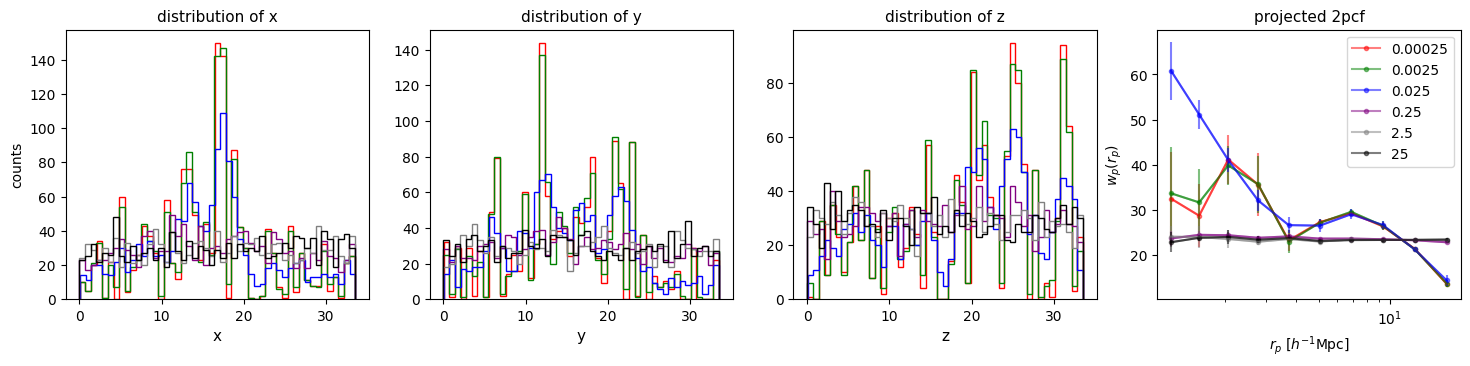

In [82]:
bin1 = np.linspace(np.min(new_pos_n4_1),np.max(new_pos_n4_1),50)
bin2 = np.linspace(np.min(new_pos_n4_2),np.max(new_pos_n4_2),50)
bin3 = np.linspace(np.min(new_pos_n4_3),np.max(new_pos_n4_3),50)
bin4 = np.linspace(np.min(new_pos_n4_4),np.max(new_pos_n4_4),50)
bin5 = np.linspace(np.min(new_pos_n4_5),np.max(new_pos_n4_5),50)
bin6 = np.linspace(np.min(new_pos_n4_6),np.max(new_pos_n4_6),50)

fig, ax = plt.subplots(1,4, figsize=(18,3.5))
ax[0].hist(new_pos_n4_1[:,0], bins=bin1, histtype='step', color= 'Red')
ax[0].hist(new_pos_n4_2[:,0], bins=bin2, histtype='step', color= 'Green')
ax[0].hist(new_pos_n4_3[:,0], bins=bin3, histtype='step', color= 'Blue')
ax[0].hist(new_pos_n4_4[:,0], bins=bin4, histtype='step', color= 'Purple')
ax[0].hist(new_pos_n4_5[:,0], bins=bin5, histtype='step', color= 'Gray')
ax[0].hist(new_pos_n4_6[:,0], bins=bin6, histtype='step', color= 'Black')
ax[0].set_title('distribution of x', fontsize=11)
ax[0].set_xlabel('x', fontsize=11)
ax[0].set_ylabel('counts')

ax[1].hist(new_pos_n4_1[:,1], bins=bin1, histtype='step', color= 'Red')
ax[1].hist(new_pos_n4_2[:,1], bins=bin2, histtype='step', color= 'Green')
ax[1].hist(new_pos_n4_3[:,1], bins=bin3, histtype='step', color= 'Blue')
ax[1].hist(new_pos_n4_4[:,1], bins=bin4, histtype='step', color= 'Purple')
ax[1].hist(new_pos_n4_5[:,1], bins=bin5, histtype='step', color= 'Gray')
ax[1].hist(new_pos_n4_6[:,1], bins=bin6, histtype='step', color= 'Black')
ax[1].set_title('distribution of y', fontsize=11)
ax[1].set_xlabel('y', fontsize=11)

ax[2].hist(new_pos_n4_1[:,2], bins=bin1, histtype='step', color= 'Red')
ax[2].hist(new_pos_n4_2[:,2], bins=bin2, histtype='step', color= 'Green')
ax[2].hist(new_pos_n4_3[:,2], bins=bin3, histtype='step', color= 'Blue')
ax[2].hist(new_pos_n4_4[:,2], bins=bin4, histtype='step', color= 'Purple')
ax[2].hist(new_pos_n4_5[:,2], bins=bin5, histtype='step', color= 'Gray')
ax[2].hist(new_pos_n4_6[:,2], bins=bin6, histtype='step', color= 'Black')
ax[2].set_title('distribution of z', fontsize=11)
ax[2].set_xlabel('z', fontsize=11)

ax[3].plot(proj_cf_n4_1[0],proj_cf_n4_1[1], marker = '.',
        color= 'Red', label='0.00025', alpha = .5)
ax[3].errorbar(proj_cf_n4_1[0], proj_cf_n4_1[1],
        yerr=uncertain_n4_1[1], color= 'Red', alpha = .5)
ax[3].plot(proj_cf_n4_2[0],proj_cf_n4_2[1], marker = '.',
        color= 'Green', label='0.0025', alpha = .5)
ax[3].errorbar(proj_cf_n4_2[0], proj_cf_n4_2[1],
        yerr=uncertain_n4_2[1], color= 'Green', alpha = .5)
ax[3].plot(proj_cf_n4_3[0],proj_cf_n4_3[1], marker = '.',
        color= 'Blue', label='0.025', alpha = .5)
ax[3].errorbar(proj_cf_n4_3[0], proj_cf_n4_3[1],
        yerr=uncertain_n4_3[1], color= 'Blue', alpha = .5)
ax[3].plot(proj_cf_n4_4[0],proj_cf_n4_4[1], marker = '.',
        color= 'Purple', label='0.25', alpha = .5)
ax[3].errorbar(proj_cf_n4_4[0], proj_cf_n4_4[1],
        yerr=uncertain_n4_4[1], color= 'Purple', alpha = .5)
ax[3].plot(proj_cf_n4_5[0],proj_cf_n4_5[1], marker = '.',
        color= 'Gray', label='2.5', alpha = .5)
ax[3].errorbar(proj_cf_n4_5[0], proj_cf_n4_5[1],
        yerr=uncertain_n4_5[1], color= 'Gray', alpha = .5)
ax[3].plot(proj_cf_n4_6[0],proj_cf_n4_6[1], marker = '.',
        color= 'Black', label='25', alpha = .5)
ax[3].errorbar(proj_cf_n4_6[0], proj_cf_n4_6[1],
        yerr=uncertain_n4_6[1], color= 'Black', alpha = .5)
ax[3].set_xlabel(r"$r_{p} \; [h^{-1} \mathrm{Mpc}]$")
ax[3].set_ylabel(r"$w_{p} (r_{p})$")
ax[3].set_title('projected 2pcf', fontsize=11)
#ax[3].set_ylim(10,100)
#ax[3].set_xlim(10e-1,10**(2))
ax[3].set_xscale('log')
ax[3].legend();

we can easily see that delta4(0.25), delta5(2.5) and delta6(25) are very different from the others

In [83]:
from scipy.stats import ttest_ind,ks_2samp

test 1

In [84]:
p_delta1 = []
for i in range(3):
    p1 = ttest_ind(pos_n4[:,i], new_pos_n4_1[:,i]).pvalue
    p_delta1.append(p1)
print('delta1 = 0.00025')    
print(p_delta1)

p_delta2 = []
for i in range(3):
    p2 = ttest_ind(pos_n4[:,i], new_pos_n4_2[:,i]).pvalue
    p_delta2.append(p2)
print('delta2 = 0.0025')
print(p_delta2)

p_delta3 = []
for i in range(3):
    p3 = ttest_ind(pos_n4[:,i], new_pos_n4_3[:,i]).pvalue
    p_delta3.append(p3)
print('delta3 = 0.025')
print(p_delta3)

p_delta4 = []
for i in range(3):
    p4 = ttest_ind(pos_n4[:,i], new_pos_n4_4[:,i]).pvalue
    p_delta4.append(p4)
print('delta4 = 0.25')
print(p_delta4)

p_delta5 = []
for i in range(3):
    p5 = ttest_ind(pos_n4[:,i], new_pos_n4_5[:,i]).pvalue
    p_delta5.append(p5)
print('delta5 = 2.5')
print(p_delta5)

p_delta6 = []
for i in range(3):
    p6 = ttest_ind(pos_n4[:,i], new_pos_n4_6[:,i]).pvalue
    p_delta6.append(p6)
print('delta6 = 25')
print(p_delta6)

delta1 = 0.00025
[0.99983240607611, 0.9994438476735281, 0.9989042281017754]
delta2 = 0.0025
[0.9983244664336686, 0.6724045865520359, 0.7153460454438201]
delta3 = 0.025
[0.8511949163498532, 0.5375113189896747, 0.48514887821024144]
delta4 = 0.25
[0.01780074045941232, 1.3123272903662696e-05, 7.58361472234739e-11]
delta5 = 2.5
[0.0004886612425737282, 3.687711835774842e-07, 3.623560955249706e-14]
delta6 = 25
[1.7042512344423675e-05, 2.15094801081124e-06, 6.909502932929357e-14]


test 2

In [85]:
p_delta1 = []
for i in range(3):
    p1 = ks_2samp(pos_n4[:,i], new_pos_n4_1[:,i]).pvalue
    p_delta1.append(p1)
print('delta1 = 0.00025')    
print(p_delta1)

p_delta2 = []
for i in range(3):
    p2 = ks_2samp(pos_n4[:,i], new_pos_n4_2[:,i]).pvalue
    p_delta2.append(p2)
print('delta2 = 0.0025')
print(p_delta2)

p_delta3 = []
for i in range(3):
    p3 = ks_2samp(pos_n4[:,i], new_pos_n4_3[:,i]).pvalue
    p_delta3.append(p3)
print('delta3 = 0.025')
print(p_delta3)

p_delta4 = []
for i in range(3):
    p4 = ks_2samp(pos_n4[:,i], new_pos_n4_4[:,i]).pvalue
    p_delta4.append(p4)
print('delta4 = 0.25')
print(p_delta4)

p_delta5 = []
for i in range(3):
    p5 = ks_2samp(pos_n4[:,i], new_pos_n4_5[:,i]).pvalue
    p_delta5.append(p5)
print('delta5 = 2.5')
print(p_delta5)

p_delta6 = []
for i in range(3):
    p6 = ks_2samp(pos_n4[:,i], new_pos_n4_6[:,i]).pvalue
    p_delta6.append(p6)
print('delta6 = 25')
print(p_delta6)

delta1 = 0.00025
[0.9096055839626442, 0.7820166375893811, 0.9956874030269554]
delta2 = 0.0025
[0.7820166375893811, 0.8108674153101658, 0.6268016893110758]
delta3 = 0.025
[0.003976474001380563, 0.06358728463410952, 0.21983696441921782]
delta4 = 0.25
[3.398274090265027e-21, 4.916091863799923e-21, 2.082106566872772e-15]
delta5 = 2.5
[7.030385069371308e-29, 2.166931982814107e-27, 4.3704176624113844e-20]
delta6 = 25
[2.1769296239086642e-33, 4.5497914962269706e-29, 2.1220119036995732e-20]


if we take a threshold value of 0.05, the highest delta such that the distributions of the x,y, and z are still drawn from the same population as the original distributions should be between delta3 = 0.025 and delta4 = 0.25

find that delta

In [164]:
delta_n4_31 = 0.04
delta_n4_32 = 0.06
delta_n4_33 = 0.08
delta_n4_34 = 0.10
delta_n4_35 = 0.12

In [165]:
# new positions for each delta

# delta 31
np.random.seed(0)
new_pos_n4_31 = pos_n4 + (np.random.normal(0, delta_n4_31, (len(gal_sample1),3)))*boxsize
for i in range(3): # periodic boundary
    new_pos_n4_31[:,i][new_pos_n4_31[:,i] < np.zeros(1)] = (
        (new_pos_n4_31[:,i][new_pos_n4_31[:,i] < np.zeros(1)]) % boxsize) + boxsize
    new_pos_n4_31[:,i][new_pos_n4_31[:,i] > boxsize] %= boxsize

# delta 32
np.random.seed(0)
new_pos_n4_32 = pos_n4 + (np.random.normal(0, delta_n4_32, (len(gal_sample1),3)))*boxsize
for i in range(3): # periodic boundary
    new_pos_n4_32[:,i][new_pos_n4_32[:,i] < np.zeros(1)] = (
        (new_pos_n4_32[:,i][new_pos_n4_32[:,i] < np.zeros(1)]) % boxsize) + boxsize
    new_pos_n4_32[:,i][new_pos_n4_32[:,i] > boxsize] %= boxsize

# delta 33
np.random.seed(0)
new_pos_n4_33 = pos_n4 + (np.random.normal(0, delta_n4_33, (len(gal_sample1),3)))*boxsize
for i in range(3): # periodic boundary
    new_pos_n4_33[:,i][new_pos_n4_33[:,i] < np.zeros(1)] = (
        (new_pos_n4_33[:,i][new_pos_n4_33[:,i] < np.zeros(1)]) % boxsize) + boxsize
    new_pos_n4_33[:,i][new_pos_n4_33[:,i] > boxsize] %= boxsize

# delta 34
np.random.seed(0)
new_pos_n4_34 = pos_n4 + (np.random.normal(0, delta_n4_34, (len(gal_sample1),3)))*boxsize
for i in range(3): # periodic boundary
    new_pos_n4_34[:,i][new_pos_n4_34[:,i] < np.zeros(1)] = (
        (new_pos_n4_34[:,i][new_pos_n4_34[:,i] < np.zeros(1)]) % boxsize) + boxsize
    new_pos_n4_34[:,i][new_pos_n4_34[:,i] > boxsize] %= boxsize

# delta 35
np.random.seed(0)
new_pos_n4_35 = pos_n4 + (np.random.normal(0, delta_n4_35, (len(gal_sample1),3)))*boxsize
for i in range(3): # periodic boundary
    new_pos_n4_35[:,i][new_pos_n4_35[:,i] < np.zeros(1)] = (
        (new_pos_n4_35[:,i][new_pos_n4_35[:,i] < np.zeros(1)]) % boxsize) + boxsize
    new_pos_n4_35[:,i][new_pos_n4_35[:,i] > boxsize] %= boxsize

In [166]:
# projected correlation function
proj_cf_n4_31 = calculate_projected_2pcf(
    data= new_pos_n4_31,
    box_size= obj.simulation.boxsize,
    binnumber=10
)
proj_cf_n4_32 = calculate_projected_2pcf(
    data= new_pos_n4_32,
    box_size= obj.simulation.boxsize,
    binnumber=10
)
proj_cf_n4_33 = calculate_projected_2pcf(
    data= new_pos_n4_33,
    box_size= obj.simulation.boxsize,
    binnumber=10
)
proj_cf_n4_34 = calculate_projected_2pcf(
    data= new_pos_n4_34,
    box_size= obj.simulation.boxsize,
    binnumber=10
)
proj_cf_n4_35 = calculate_projected_2pcf(
    data= new_pos_n4_35,
    box_size= obj.simulation.boxsize,
    binnumber=10
)

# uncertainty using k-fold method
uncertain_n4_31 = find_ptpcf_uncertainty_kfold(
    positions= new_pos_n4_31,
    size_box= obj.simulation.boxsize,
    number_bin= 10
)
uncertain_n4_32 = find_ptpcf_uncertainty_kfold(
    positions= new_pos_n4_32,
    size_box= obj.simulation.boxsize,
    number_bin= 10
)
uncertain_n4_33 = find_ptpcf_uncertainty_kfold(
    positions= new_pos_n4_33,
    size_box= obj.simulation.boxsize,
    number_bin= 10
)
uncertain_n4_34 = find_ptpcf_uncertainty_kfold(
    positions= new_pos_n4_34,
    size_box= obj.simulation.boxsize,
    number_bin= 10
)
uncertain_n4_35 = find_ptpcf_uncertainty_kfold(
    positions= new_pos_n4_35,
    size_box= obj.simulation.boxsize,
    number_bin= 10
)

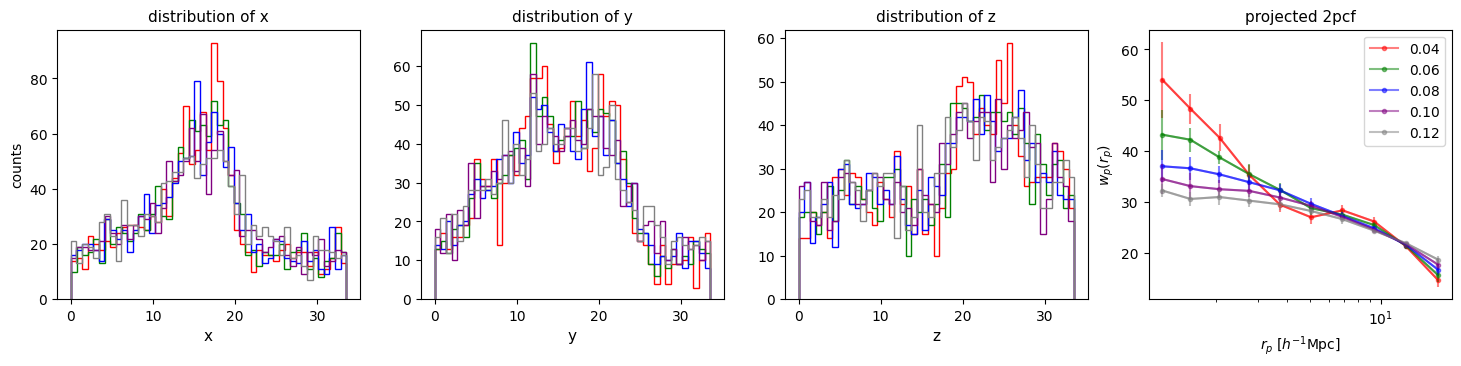

In [170]:
bin31 = np.linspace(np.min(new_pos_n4_31),np.max(new_pos_n4_31),50)
bin32 = np.linspace(np.min(new_pos_n4_32),np.max(new_pos_n4_32),50)
bin33 = np.linspace(np.min(new_pos_n4_33),np.max(new_pos_n4_33),50)
bin34 = np.linspace(np.min(new_pos_n4_34),np.max(new_pos_n4_34),50)
bin35 = np.linspace(np.min(new_pos_n4_35),np.max(new_pos_n4_35),50)


fig, ax = plt.subplots(1,4, figsize=(18,3.5))
ax[0].hist(new_pos_n4_31[:,0], bins=bin31, histtype='step', color= 'Red')
ax[0].hist(new_pos_n4_32[:,0], bins=bin32, histtype='step', color= 'Green')
ax[0].hist(new_pos_n4_33[:,0], bins=bin33, histtype='step', color= 'Blue')
ax[0].hist(new_pos_n4_34[:,0], bins=bin34, histtype='step', color= 'Purple')
ax[0].hist(new_pos_n4_35[:,0], bins=bin35, histtype='step', color= 'Gray')
#ax[0].hist(new_pos_n4_6[:,0], bins=bin6, histtype='step', color= 'Black')
ax[0].set_title('distribution of x', fontsize=11)
ax[0].set_xlabel('x', fontsize=11)
ax[0].set_ylabel('counts')

ax[1].hist(new_pos_n4_31[:,1], bins=bin31, histtype='step', color= 'Red')
ax[1].hist(new_pos_n4_32[:,1], bins=bin32, histtype='step', color= 'Green')
ax[1].hist(new_pos_n4_33[:,1], bins=bin33, histtype='step', color= 'Blue')
ax[1].hist(new_pos_n4_34[:,1], bins=bin34, histtype='step', color= 'Purple')
ax[1].hist(new_pos_n4_35[:,1], bins=bin35, histtype='step', color= 'Gray')
#ax[1].hist(new_pos_n4_6[:,1], bins=bin6, histtype='step', color= 'Black')
ax[1].set_title('distribution of y', fontsize=11)
ax[1].set_xlabel('y', fontsize=11)

ax[2].hist(new_pos_n4_31[:,2], bins=bin31, histtype='step', color= 'Red')
ax[2].hist(new_pos_n4_32[:,2], bins=bin32, histtype='step', color= 'Green')
ax[2].hist(new_pos_n4_33[:,2], bins=bin33, histtype='step', color= 'Blue')
ax[2].hist(new_pos_n4_34[:,2], bins=bin34, histtype='step', color= 'Purple')
ax[2].hist(new_pos_n4_35[:,2], bins=bin35, histtype='step', color= 'Gray')
#ax[2].hist(new_pos_n4_6[:,2], bins=bin6, histtype='step', color= 'Black')
ax[2].set_title('distribution of z', fontsize=11)
ax[2].set_xlabel('z', fontsize=11)

ax[3].plot(proj_cf_n4_31[0],proj_cf_n4_31[1], marker = '.',
        color= 'Red', label='0.04', alpha = .5)
ax[3].errorbar(proj_cf_n4_31[0], proj_cf_n4_31[1],
        yerr=uncertain_n4_31[1], color= 'Red', alpha = .5)
ax[3].plot(proj_cf_n4_32[0],proj_cf_n4_32[1], marker = '.',
        color= 'Green', label='0.06', alpha = .5)
ax[3].errorbar(proj_cf_n4_32[0], proj_cf_n4_32[1],
        yerr=uncertain_n4_32[1], color= 'Green', alpha = .5)
ax[3].plot(proj_cf_n4_33[0],proj_cf_n4_33[1], marker = '.',
        color= 'Blue', label='0.08', alpha = .5)
ax[3].errorbar(proj_cf_n4_33[0], proj_cf_n4_33[1],
        yerr=uncertain_n4_33[1], color= 'Blue', alpha = .5)
ax[3].plot(proj_cf_n4_34[0],proj_cf_n4_34[1], marker = '.',
        color= 'Purple', label='0.10', alpha = .5)
ax[3].errorbar(proj_cf_n4_34[0], proj_cf_n4_34[1],
        yerr=uncertain_n4_34[1], color= 'Purple', alpha = .5)
ax[3].plot(proj_cf_n4_35[0],proj_cf_n4_35[1], marker = '.',
        color= 'Gray', label='0.12', alpha = .5)
ax[3].errorbar(proj_cf_n4_35[0], proj_cf_n4_35[1],
        yerr=uncertain_n4_35[1], color= 'Gray', alpha = .5)
#ax[3].plot(proj_cf_n4_6[0],proj_cf_n4_6[1], marker = '.',
#        color= 'Black', label='25', alpha = .5)
#ax[3].errorbar(proj_cf_n4_6[0], proj_cf_n4_6[1],
#        yerr=uncertain_n4_6[1], color= 'Black', alpha = .5)
ax[3].set_xlabel(r"$r_{p} \; [h^{-1} \mathrm{Mpc}]$")
ax[3].set_ylabel(r"$w_{p} (r_{p})$")
ax[3].set_title('projected 2pcf', fontsize=11)
#ax[3].set_ylim(10,100)
#ax[3].set_xlim(10e-1,10**(2))
ax[3].set_xscale('log')
ax[3].legend();

test 1

In [171]:
p_delta31 = []
for i in range(3):
    p31 = ttest_ind(pos_n4[:,i], new_pos_n4_31[:,i]).pvalue
    p_delta31.append(p31)
print('delta31 = 0.04')    
print(p_delta31)

p_delta32 = []
for i in range(3):
    p32 = ttest_ind(pos_n4[:,i], new_pos_n4_32[:,i]).pvalue
    p_delta32.append(p32)
print('delta32 = 0.06')
print(p_delta32)

p_delta33 = []
for i in range(3):
    p33 = ttest_ind(pos_n4[:,i], new_pos_n4_33[:,i]).pvalue
    p_delta33.append(p33)
print('delta33 = 0.08')
print(p_delta33)

p_delta34 = []
for i in range(3):
    p34 = ttest_ind(pos_n4[:,i], new_pos_n4_34[:,i]).pvalue
    p_delta34.append(p34)
print('delta34 = 0.10')
print(p_delta34)

p_delta35 = []
for i in range(3):
    p35 = ttest_ind(pos_n4[:,i], new_pos_n4_35[:,i]).pvalue
    p_delta35.append(p35)
print('delta34 = 0.12')
print(p_delta35)

delta31 = 0.04
[0.9073039421948181, 0.40723920552964477, 0.23105650723289378]
delta32 = 0.06
[0.9082208635038238, 0.23367908630584053, 0.053648485814868564]
delta33 = 0.08
[0.7549213362055706, 0.1959724613365239, 0.01176533027625285]
delta34 = 0.10
[0.9347947601562354, 0.10168043065742102, 0.0015130045908780007]
delta34 = 0.12
[0.9867112359617004, 0.040223372988127004, 0.0013483423219576433]


Here, the lowest p-values > 0.05 (which means no significant evidence to suggest a difference between the distributions) could be for delta = 0.06</br>
But the p-value is very high for the distribution of x. 

test 2

In [172]:
p_delta31 = []
for i in range(3):
    p31 = ks_2samp(pos_n4[:,i], new_pos_n4_31[:,i]).pvalue
    p_delta31.append(p31)
print('delta31 = 0.04')    
print(p_delta31)

p_delta32 = []
for i in range(3):
    p32 = ks_2samp(pos_n4[:,i], new_pos_n4_32[:,i]).pvalue
    p_delta32.append(p32)
print('delta32 = 0.06')
print(p_delta32)

p_delta33 = []
for i in range(3):
    p33 = ks_2samp(pos_n4[:,i], new_pos_n4_33[:,i]).pvalue
    p_delta33.append(p33)
print('delta33 = 0.08')
print(p_delta33)

p_delta34 = []
for i in range(3):
    p34 = ks_2samp(pos_n4[:,i], new_pos_n4_34[:,i]).pvalue
    p_delta34.append(p34)
print('delta34 = 0.10')
print(p_delta34)

p_delta35 = []
for i in range(3):
    p35 = ks_2samp(pos_n4[:,i], new_pos_n4_35[:,i]).pvalue
    p_delta35.append(p35)
print('delta35 = 0.12')
print(p_delta35)

delta31 = 0.04
[0.0015198782345198548, 0.0343171855511808, 0.07722337814996343]
delta32 = 0.06
[0.0017511390404507951, 0.02762617749561424, 0.006678433561833653]
delta33 = 0.08
[0.0006307230620304752, 0.003042480574000998, 0.0006307230620304752]
delta34 = 0.10
[3.9573324029784845e-05, 0.0002487401458160905, 1.6214225280239034e-05]
delta35 = 0.12
[5.303420040172138e-06, 5.303420040172138e-06, 2.975520620279578e-06]


Here, delta could be less than 0.04</br>
Because p-values for y and especially x distributions are still lower than the threshold value 0.05